### simplified self attention

embedding vector do not capture the relationship between the words or he do not know how much attention is give to a word 

In [346]:
import torch 
import numpy as np
import matplotlib.pyplot as plt

In [347]:
inputs=torch.tensor([[0.22,0.44,0.56], # your 
                    [0.33,-0.144,0.756], # journey
                    [0.22,0.344,0.856], # starts
                    [-0.722,-0.644,-0.356], # with
                    [0.022,0.744,0.1356], # one
                    [0.122,0.044,0.956]]) # step 

In [348]:

words = ["your", "journey", "starts", "with", "one", "step"]

# Extract x, y, z coordinates
x_coords = inputs[:, 0].numpy()
y_coords = inputs[:, 1].numpy()
z_coords = inputs[:, 2].numpy()

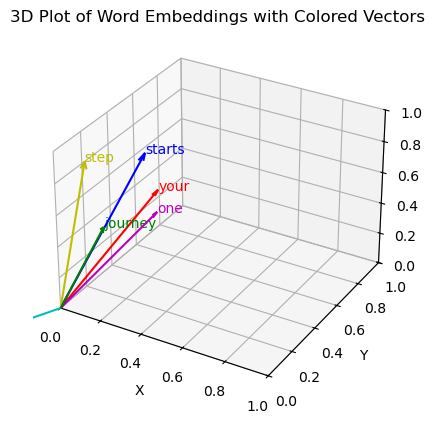

In [349]:
# Create 3D plot with vectors from origin to each point, using different colors
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

# Define a list of colors for the vectors
colors = ['r', 'g', 'b', 'c', 'm', 'y']

# Plot each vector with a different color and annotate with the corresponding word
for (x, y, z, word, color) in zip(x_coords, y_coords, z_coords, words, colors):
    # Draw vector from origin to the point (x, y, z) with specified color and smaller arrow length ratio
    ax.quiver(0, 0, 0, x, y, z, color=color, arrow_length_ratio=0.05)
    ax.text(x, y, z, word, fontsize=10, color=color)

# Set labels for axes
ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Z')

# Set plot limits to keep arrows within the plot boundaries
ax.set_xlim([0, 1])
ax.set_ylim([0, 1])
ax.set_zlim([0, 1])

plt.title('3D Plot of Word Embeddings with Colored Vectors')
plt.show()


In [350]:
query=inputs[1] # journey
a21=np.dot(query,inputs[0]) # your - q -> attention value
a22=np.dot(query,inputs[1]) # journey - q -> attention value
a23=np.dot(query,inputs[2]) # starts - q -> attention value
a24=np.dot(query,inputs[3]) # with - q -> attention value
a25=np.dot(query,inputs[4]) # one - q -> attention value
a26=np.dot(query,inputs[5]) # step - q -> attention value

print("attention score of journey=",a21,a22,a23,a24,a25,a26)

attention score of journey= 0.4326 0.70117193 0.6702 -0.41466004 0.0026376024 0.7566599


In [351]:
## find attention score of query = journey
attention_score_2=[]
for i,value in enumerate(inputs):
    attention_score_2.append(np.dot(query,value))

print(attention_score_2)
print("sum=",np.sum(attention_score_2))

[0.4326, 0.70117193, 0.6702, -0.41466004, 0.0026376024, 0.7566599]
sum= 2.1486094


## normalize 

In [352]:
attention_weight_2=[]
for i ,v in enumerate(inputs):
    attention_weight_2.append(attention_score_2[i]/np.sum(attention_score_2))

print("attention_weight_2",attention_weight_2)
print("sum=",np.sum(attention_weight_2))

attention_weight_2 [0.20133953, 0.32633755, 0.31192267, -0.19298996, 0.0012275858, 0.35216263]
sum= 1.0


## normalize with softmax 
it give always positive better for the %

In [353]:
attention_score_21=torch.zeros(len(inputs))
for i,v in enumerate(inputs):
    attention_score_21[i] = torch.dot(query,v)
## bec torch do not support numpy sum it need to be used torch
attention_weight_21=torch.zeros(len(inputs))
for i ,v in enumerate(inputs):
    attention_weight_21[i]=torch.exp(attention_score_21[i])/torch.sum(torch.exp(attention_score_21))
print("softmax=",attention_weight_21)
print("sum=",torch.sum(attention_weight_21))

softmax= tensor([0.1656, 0.2166, 0.2100, 0.0710, 0.1077, 0.2290])
sum= tensor(1.)


In [354]:
## context vector of query
context_vector=torch.zeros(len(inputs[0]))
print(context_vector)
for i ,v in enumerate(inputs):
    context_vector+=attention_weight_21[i]*v
print("context_ vector of 2 =",context_vector)
print("your=",inputs[0])
print("attention_wt_wt21(journey-your)=",attention_weight_21[0])
print(inputs[0]*attention_weight_21[0])

tensor([0., 0., 0.])
context_ vector of 2 = tensor([0.1332, 0.1584, 0.6446])
your= tensor([0.2200, 0.4400, 0.5600])
attention_wt_wt21(journey-your)= tensor(0.1656)
tensor([0.0364, 0.0729, 0.0927])


## attention score Matrix

In [355]:
attention_sc_m=inputs@inputs.T
print(attention_sc_m)

tensor([[ 0.5556,  0.4326,  0.6791, -0.6416,  0.4081,  0.5816],
        [ 0.4326,  0.7012,  0.6702, -0.4147,  0.0026,  0.7567],
        [ 0.6791,  0.6702,  0.8995, -0.6851,  0.3768,  0.8603],
        [-0.6416, -0.4147, -0.6851,  1.0628, -0.5433, -0.4568],
        [ 0.4081,  0.0026,  0.3768, -0.5433,  0.5724,  0.1651],
        [ 0.5816,  0.7567,  0.8603, -0.4568,  0.1651,  0.9308]])


### attention weight Matric

In [356]:
test=torch.tensor([[1,1,1,1,1,1],
                   [1,1,1,1,1,1]])
print("dim =0 ", torch.sum(test,dim=0))
print("dim =1 ", torch.sum(test,dim=-1)) ## its do the row wise adding

dim =0  tensor([2, 2, 2, 2, 2, 2])
dim =1  tensor([6, 6])


In [357]:
attention_sc_exp=torch.exp(attention_sc_m) ## convert into exponent
print(attention_sc_exp)
print("sum dim -1=",torch.sum(attention_sc_exp,dim=-1))
print("sum dim 0=",torch.sum(attention_sc_exp,dim=0))
attention_wt_m=attention_sc_exp/torch.sum(attention_sc_exp,dim=-1)
print(attention_wt_m)

tensor([[1.7430, 1.5413, 1.9721, 0.5265, 1.5040, 1.7888],
        [1.5413, 2.0161, 1.9546, 0.6606, 1.0026, 2.1311],
        [1.9721, 1.9546, 2.4583, 0.5040, 1.4577, 2.3639],
        [0.5265, 0.6606, 0.5040, 2.8943, 0.5808, 0.6333],
        [1.5040, 1.0026, 1.4577, 0.5808, 1.7725, 1.1795],
        [1.7888, 2.1311, 2.3639, 0.6333, 1.1795, 2.5364]])
sum dim -1= tensor([ 9.0757,  9.3064, 10.7107,  5.7996,  7.4972, 10.6331])
sum dim 0= tensor([ 9.0757,  9.3064, 10.7107,  5.7996,  7.4972, 10.6331])
tensor([[0.1920, 0.1656, 0.1841, 0.0908, 0.2006, 0.1682],
        [0.1698, 0.2166, 0.1825, 0.1139, 0.1337, 0.2004],
        [0.2173, 0.2100, 0.2295, 0.0869, 0.1944, 0.2223],
        [0.0580, 0.0710, 0.0471, 0.4991, 0.0775, 0.0596],
        [0.1657, 0.1077, 0.1361, 0.1002, 0.2364, 0.1109],
        [0.1971, 0.2290, 0.2207, 0.1092, 0.1573, 0.2385]])


## context vector

In [358]:
print(attention_wt_m@inputs) 

tensor([[ 0.0968,  0.2222,  0.5461],
        [ 0.0942,  0.1413,  0.5843],
        [ 0.1363,  0.2428,  0.6849],
        [-0.3048, -0.2296,  0.0162],
        [ 0.0484,  0.2205,  0.3932],
        [ 0.1212,  0.1869,  0.6829]])
